# Sustained fps vs data size

- One panel per primitive, native size units on x
- Color = backend
- Solid = during interaction (mean of pan / zoom / drag), band = range across those modes
- Thin dotted = no interaction baseline

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

RESULTS = "results/results.csv"
INTERACTION_MODES = ["pan", "zoom", "drag"]
PRIMITIVES = {
    "image": "image size (px)",
    "scatter": "scatter points",
    "line": "line points",
}
BACKENDS = {"shared": ("shared buffer", "#2a78d6"), "naive": ("host naive", "#eb6834")}
REF_HZ = [60, 120]

In [5]:
df = pd.read_csv(RESULTS)

per_mode = df.groupby(["primitive", "backend", "mode", "size"])["fps_mean"].mean().reset_index()

baseline = per_mode.query("mode == 'none'")
interactive = (
    per_mode.query("mode in @INTERACTION_MODES")
    .groupby(["primitive", "backend", "size"])["fps_mean"]
    .agg(["mean", "min", "max"])
    .reset_index()
)
interactive

,primitive,backend,size,mean,min,max
0,image,naive,256,335.216813,334.370199,335.920533
1,image,naive,512,222.620924,221.320508,223.528316
2,image,naive,1024,82.313386,82.132268,82.569610
3,image,naive,2048,18.802796,18.772893,18.828651
4,image,naive,4096,4.698229,4.688265,4.709933
5,image,shared,256,408.758277,405.908899,411.436496
6,image,shared,512,405.034231,400.653905,408.079717
7,image,shared,1024,400.229222,396.952979,406.708748
8,image,shared,2048,319.218025,317.541886,321.463829
9,image,shared,4096,119.594217,118.782292,121.048098


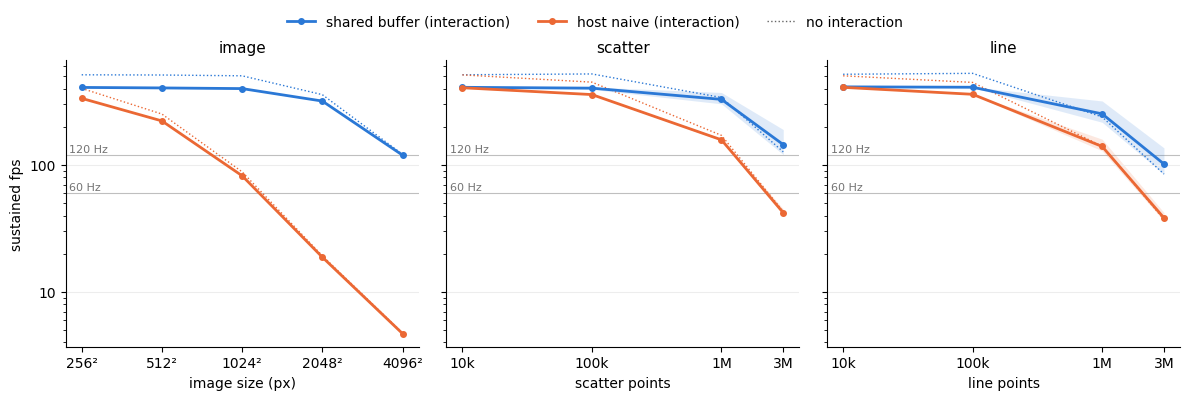

In [6]:
plt.rcParams.update({"font.size": 10, "axes.titlesize": 11})


def fmt_size(v, primitive):
    if primitive == "image":
        return f"{int(v)}²"
    return f"{v / 1e6:g}M" if v >= 1e6 else f"{v / 1e3:g}k"


fig, axes = plt.subplots(1, len(PRIMITIVES), figsize=(12, 3.8), sharey=True)

for ax, (primitive, xlabel) in zip(axes, PRIMITIVES.items()):
    for hz in REF_HZ:
        ax.axhline(hz, color="0.75", lw=0.8, zorder=0)
        ax.text(0.01, hz * 1.06, f"{hz} Hz", transform=ax.get_yaxis_transform(), fontsize=8, color="0.45")

    for backend, (label, color) in BACKENDS.items():
        b = baseline.query("primitive == @primitive and backend == @backend").sort_values("size")
        ax.plot(b["size"], b["fps_mean"], color=color, lw=1, ls=":", zorder=2)

        d = interactive.query("primitive == @primitive and backend == @backend").sort_values("size")
        if d.empty:
            continue
        ax.fill_between(d["size"], d["min"], d["max"], color=color, alpha=0.15, lw=0, zorder=1)
        ax.plot(d["size"], d["mean"], color=color, lw=2, marker="o", ms=4, zorder=3)

    ax.set_title(primitive)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    sizes = sorted(df.query("primitive == @primitive")["size"].unique())
    ax.xaxis.set_major_locator(mticker.FixedLocator(sizes))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _, p=primitive: fmt_size(v, p)))
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.grid(True, which="major", axis="y", color="0.93", lw=0.8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

axes[0].set_ylabel("sustained fps")
axes[0].set_ylim(bottom=max(1, axes[0].get_ylim()[0]))

handles = [plt.Line2D([], [], color=c, lw=2, marker="o", ms=4) for _, c in BACKENDS.values()]
handles.append(plt.Line2D([], [], color="0.4", lw=1, ls=":"))
labels = [f"{l} (interaction)" for l, _ in BACKENDS.values()] + ["no interaction"]
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.06))

fig.tight_layout()
#fig.savefig("results/fps_vs_size.png", dpi=200, bbox_inches="tight")
plt.show()

## Shared vs naive speedup during interaction

In [ ]:
speedup = interactive.pivot_table(index=["primitive", "size"], columns="backend", values="mean")
speedup["speedup"] = speedup["shared"] / speedup["naive"]
speedup.round(1)

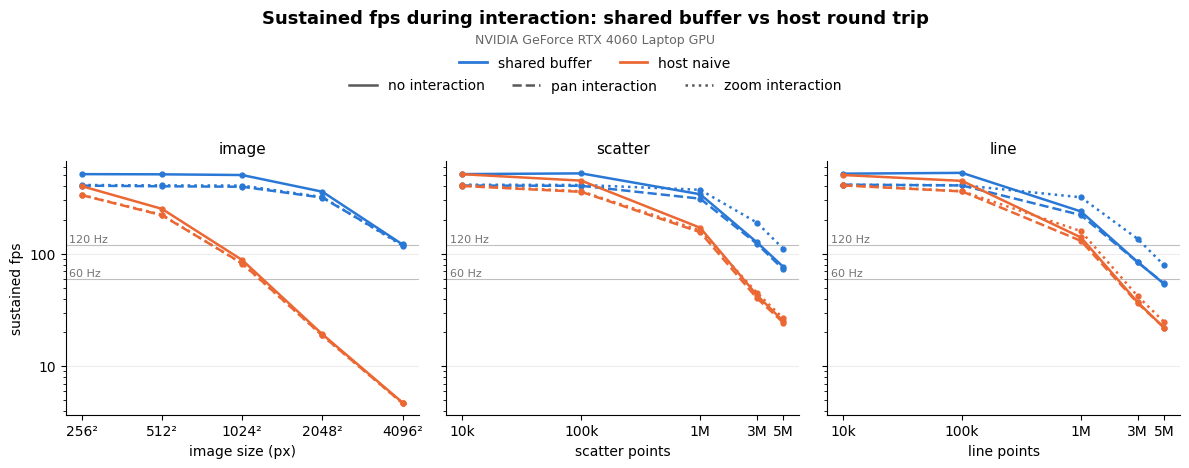

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

RESULTS = "results/results.csv"
MODES = {"none": "-", "pan": "--", "zoom": ":"}
PRIMITIVES = {
    "image": "image size (px)",
    "scatter": "scatter points",
    "line": "line points",
}
BACKENDS = {"shared": ("shared buffer", "#2a78d6"), "naive": ("host naive", "#eb6834")}
REF_HZ = [60, 120]
TITLE = "Sustained fps during interaction: shared buffer vs host round trip"
GPU = "NVIDIA GeForce RTX 4060 Laptop GPU"

plt.rcParams.update({"font.size": 10, "axes.titlesize": 11})

df = pd.read_csv(RESULTS).query("mode in @MODES")
summary = df.groupby(["mode", "primitive", "backend", "size"])["fps_mean"].mean().reset_index(name="fps")


def fmt_size(v, primitive):
    if primitive == "image":
        return f"{int(v)}²"
    return f"{v / 1e6:g}M" if v >= 1e6 else f"{v / 1e3:g}k"


fig, axes = plt.subplots(1, len(PRIMITIVES), figsize=(12, 3.8), sharey=True)

for ax, (primitive, xlabel) in zip(axes, PRIMITIVES.items()):
    for hz in REF_HZ:
        ax.axhline(hz, color="0.75", lw=0.8, zorder=0)
        ax.text(0.01, hz * 1.06, f"{hz} Hz", transform=ax.get_yaxis_transform(), fontsize=8, color="0.45")

    for backend, (_, color) in BACKENDS.items():
        for mode, ls in MODES.items():
            d = summary.query("mode == @mode and primitive == @primitive and backend == @backend").sort_values("size")
            ax.plot(d["size"], d["fps"], color=color, ls=ls, lw=1.8, marker="o", ms=3.5, zorder=3)

    sizes = sorted(df.query("primitive == @primitive")["size"].unique())
    ax.set_title(primitive)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_locator(mticker.FixedLocator(sizes))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _, p=primitive: fmt_size(v, p)))
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.grid(True, which="major", axis="y", color="0.93", lw=0.8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

axes[0].set_ylabel("sustained fps")

# two-part legend: color = backend, line style = mode
backend_handles = [plt.Line2D([], [], color=c, lw=2) for _, c in BACKENDS.values()]
backend_labels = [l for l, _ in BACKENDS.values()]

mode_handles = [plt.Line2D([], [], color="0.35", lw=1.8, ls=ls) for ls in MODES.values()]
mode_labels = ["no interaction" if m == "none" else f"{m} interaction" for m in MODES]

fig.suptitle(TITLE, y=1.22, fontsize=13, fontweight="bold")
fig.text(0.5, 1.13, GPU, ha="center", fontsize=9, color="0.4")
fig.legend(backend_handles, backend_labels, loc="upper center", ncol=len(backend_handles),
           frameon=False, bbox_to_anchor=(0.5, 1.13))
fig.legend(mode_handles, mode_labels, loc="upper center", ncol=len(mode_handles),
           frameon=False, bbox_to_anchor=(0.5, 1.07))

# fig.suptitle(TITLE, y=1.16, fontsize=13, fontweight="bold")
# fig.text(0.5, 1.07, GPU, ha="center", fontsize=9, color="0.4")
# fig.legend(handles, labels, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, 1.05))

fig.tight_layout()
#fig.savefig("results/fps_vs_size.png", dpi=200, bbox_inches="tight")
plt.show()

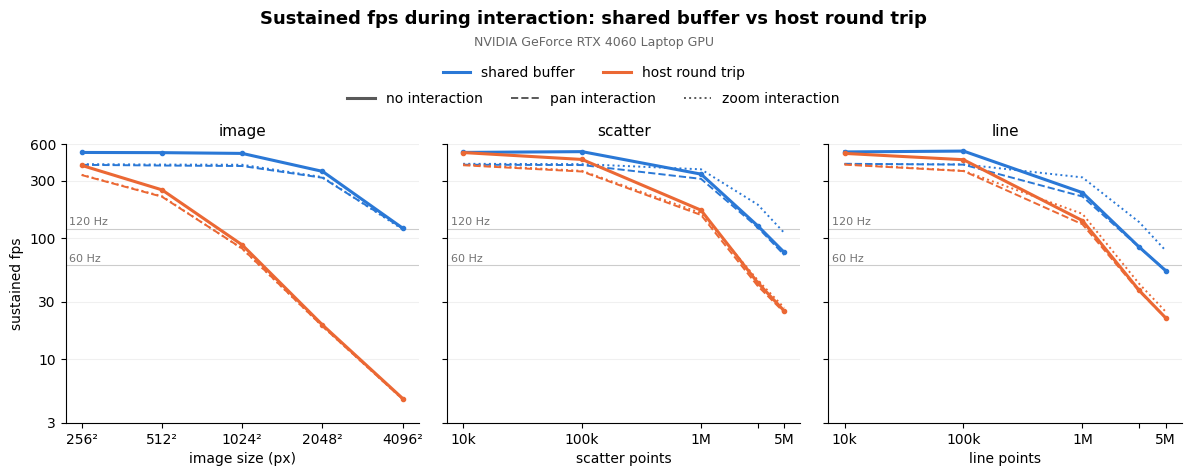

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

RESULTS = "results/results.csv"
MODES = {"none": "-", "pan": "--", "zoom": ":"}
MODE_LW = {"none": 2.2, "pan": 1.4, "zoom": 1.4}
PRIMITIVES = {
    "image": "image size (px)",
    "scatter": "scatter points",
    "line": "line points",
}
BACKENDS = {"shared": ("shared buffer", "#2a78d6"), "naive": ("host round trip", "#eb6834")}
REF_HZ = [60, 120]
Y_TICKS = [3, 10, 30, 100, 300, 600]
HIDE_X_TICKS = {3_000_000}  # avoid 3M/5M collision
TITLE = "Sustained fps during interaction: shared buffer vs host round trip"
GPU = "NVIDIA GeForce RTX 4060 Laptop GPU"

plt.rcParams.update({"font.size": 10, "axes.titlesize": 11})

df = pd.read_csv(RESULTS).query("mode in @MODES")
summary = df.groupby(["mode", "primitive", "backend", "size"])["fps_mean"].mean().reset_index(name="fps")


def fmt_size(v, primitive):
    if primitive == "image":
        return f"{int(v)}²"
    if v in HIDE_X_TICKS:
        return ""
    return f"{v / 1e6:g}M" if v >= 1e6 else f"{v / 1e3:g}k"


fig, axes = plt.subplots(1, len(PRIMITIVES), figsize=(12, 4.8), sharey=True)
fig.subplots_adjust(top=0.70, bottom=0.12, left=0.06, right=0.99, wspace=0.08)

for ax, (primitive, xlabel) in zip(axes, PRIMITIVES.items()):
    for hz in REF_HZ:
        ax.axhline(hz, color="0.8", lw=0.8, zorder=0)
        ax.text(0.01, hz * 1.07, f"{hz} Hz", transform=ax.get_yaxis_transform(),
                ha="left", fontsize=8, color="0.45")

    for backend, (_, color) in BACKENDS.items():
        for mode, ls in MODES.items():
            d = summary.query("mode == @mode and primitive == @primitive and backend == @backend").sort_values("size")
            ax.plot(d["size"], d["fps"], color=color, ls=ls, lw=MODE_LW[mode],
                    marker="o" if mode == "none" else None, ms=3, zorder=3 if mode == "none" else 2)

    sizes = sorted(df.query("primitive == @primitive")["size"].unique())
    ax.set_title(primitive)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_locator(mticker.FixedLocator(sizes))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _, p=primitive: fmt_size(v, p)))
    ax.set_yticks(Y_TICKS)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.set_ylim(Y_TICKS[0], Y_TICKS[-1])
    ax.grid(True, which="major", axis="y", color="0.94", lw=0.8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

axes[0].set_ylabel("sustained fps")

# two-row legend: color = backend, line style = mode
backend_handles = [plt.Line2D([], [], color=c, lw=2.2) for _, c in BACKENDS.values()]
backend_labels = [l for l, _ in BACKENDS.values()]
mode_handles = [plt.Line2D([], [], color="0.35", lw=MODE_LW[m], ls=ls) for m, ls in MODES.items()]
mode_labels = ["no interaction" if m == "none" else f"{m} interaction" for m in MODES]

fig.suptitle(TITLE, y=0.98, fontsize=13, fontweight="bold")
fig.text(0.5, 0.905, GPU, ha="center", fontsize=9, color="0.4")
fig.legend(backend_handles, backend_labels, loc="upper center", ncol=len(backend_handles),
           frameon=False, bbox_to_anchor=(0.5, 0.89))
fig.legend(mode_handles, mode_labels, loc="upper center", ncol=len(mode_handles),
           frameon=False, bbox_to_anchor=(0.5, 0.835))

fig.savefig("results/fps_vs_size.png", dpi=200, bbox_inches="tight")
plt.show()

In [19]:
speedup = (
    summary.pivot_table(index=["primitive", "size", "mode"], columns="backend", values="fps")
    .assign(speedup=lambda t: t["shared"] / t["naive"])
    .reset_index()
    .pivot_table(index=["primitive", "size"], columns="mode", values="speedup")
    [list(MODES)]
)

speedup = speedup.reindex(list(PRIMITIVES), level="primitive")
speedup.index = pd.MultiIndex.from_tuples(
    [(p, fmt_size(s, p) or f"{s / 1e6:g}M") for p, s in speedup.index],
    names=["primitive", "size"],
)
speedup.columns = ["no interaction" if m == "none" else m for m in speedup.columns]
speedup.columns.name = "shared ÷ naive"

speedup.style.format("{:.1f}×").background_gradient(cmap="Blues", axis=None, vmin=1)

,,,frames,D2H MB/frame,D2H ms/frame
primitive,size,backend,,,
image,4096²,shared,891,0.0,0.0
scatter,5M,shared,561,0.1,0.0
line,5M,shared,411,0.1,0.0
image,4096²,naive,35,195.6,61.1
scatter,5M,naive,186,54.8,17.3
line,5M,naive,169,55.0,17.1


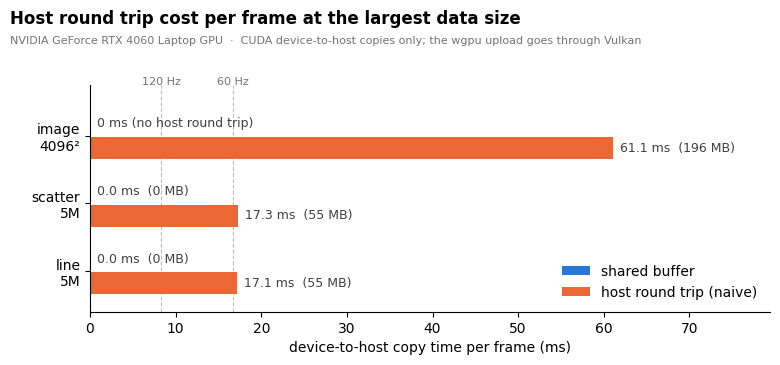

In [30]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

NSYS_DIR = Path("results/nsys")
CASES = {"image": 4096, "scatter": 5_000_000, "line": 5_000_000}
BACKENDS = {"shared": ("shared buffer", "#2a78d6"), "naive": ("host round trip (naive)", "#eb6834")}
D2H = "[CUDA memcpy Device-to-Host]"
FRAME_BUDGET_MS = {"120 Hz": 1000 / 120, "60 Hz": 1000 / 60}
TITLE = "Host round trip cost per frame at the largest data size"
GPU = "NVIDIA GeForce RTX 4060 Laptop GPU"
NOTE = "CUDA device-to-host copies only; the wgpu upload goes through Vulkan"


def read_report(path):
    try:
        return pd.read_csv(path)
    except (FileNotFoundError, pd.errors.EmptyDataError):
        return pd.DataFrame()


def size_label(primitive, size):
    return f"{size}²" if primitive == "image" else f"{size / 1e6:g}M"


rows = []
for backend in BACKENDS:
    for primitive, size in CASES.items():
        stem = NSYS_DIR / f"{backend}_{primitive}_{size}"
        sizes = read_report(f"{stem}_cuda_gpu_mem_size_sum.csv")
        times = read_report(f"{stem}_cuda_gpu_mem_time_sum.csv")
        kerns = read_report(f"{stem}_cuda_gpu_kern_sum.csv")

        # every compute kernel launches once per frame
        n_frames = int(kerns["Instances"].max()) if not kerns.empty else 1

        s = sizes[sizes["Operation"] == D2H] if not sizes.empty else None
        t = times[times["Operation"] == D2H] if not times.empty else None
        rows.append({
            "backend": backend,
            "primitive": primitive,
            "size": size_label(primitive, size),
            "frames": n_frames,
            "D2H MB/frame": s["Total (MB)"].sum() / n_frames if s is not None else 0.0,
            "D2H ms/frame": t["Total Time (ns)"].sum() / 1e6 / n_frames if t is not None else 0.0,
        })

copies = pd.DataFrame(rows)
copy_table = copies.set_index(["primitive", "size", "backend"])[["frames", "D2H MB/frame", "D2H ms/frame"]]
display(copy_table.style.format("{:.1f}").format("{:d}", subset=["frames"]))

# plot
primitives = list(CASES)
bar_h = 0.36
fig, ax = plt.subplots(figsize=(8, 3.6))
fig.subplots_adjust(top=0.78, bottom=0.15, left=0.12, right=0.97)

for i, (backend, (label, color)) in enumerate(BACKENDS.items()):
    d = copies[copies["backend"] == backend].set_index("primitive").loc[primitives]
    y = [p + (i - 0.5) * bar_h for p in range(len(primitives))]
    ax.barh(y, d["D2H ms/frame"], height=bar_h * 0.9, color=color, label=label)

    for yi, ms, mb in zip(y, d["D2H ms/frame"], d["D2H MB/frame"]):
        text = "0 ms (no host round trip)" if ms == 0 else f"{ms:.1f} ms  ({mb:.0f} MB)"
        ax.text(ms + 0.8, yi, text, va="center", fontsize=9, color="0.25")

for name, ms in FRAME_BUDGET_MS.items():
    ax.axvline(ms, color="0.75", lw=0.8, ls="--", zorder=0)
    ax.text(ms, -0.72, name, fontsize=8, color="0.45", ha="center", va="bottom")

ax.set_yticks(range(len(primitives)))
ax.set_yticklabels([f"{p}\n{size_label(p, CASES[p])}" for p in primitives])
ax.set_ylim(len(primitives) - 0.4, -0.75)
ax.set_xlim(0, copies["D2H ms/frame"].max() * 1.3)
ax.set_xlabel("device-to-host copy time per frame (ms)")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, loc="lower right")

fig.text(0.02, 0.95, TITLE, fontsize=12, fontweight="bold")
fig.text(0.02, 0.895, f"{GPU}  ·  {NOTE}", fontsize=8, color="0.45")

fig.savefig("results/nsys_host_roundtrip.png", dpi=200, bbox_inches="tight")
plt.show()

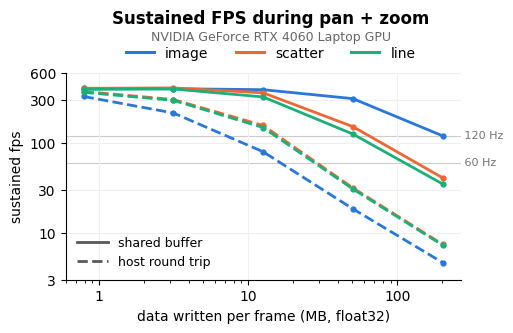

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

RESULTS = "results/panzoom.csv"
MODE = "panzoom"
PRIMITIVES = {"image": "#2a78d6", "scatter": "#eb6834", "line": "#1baf7a"}
BACKENDS = {"shared": ("shared buffer", "-"), "naive": ("host round trip", "--")}
REF_HZ = [60, 120]
TITLE = "Sustained FPS during pan + zoom"
GPU = "NVIDIA GeForce RTX 4060 Laptop GPU"

plt.rcParams.update({"font.size": 10})

df = pd.read_csv(RESULTS).query("mode == @MODE").copy()

# float32 bytes per frame: image (H, W, 3), points (N, 3)
df["mb_per_frame"] = df["size"].where(df["primitive"] != "image", df["size"] ** 2) * 3 * 4 / 1e6

summary = (
    df.groupby(["primitive", "backend", "size", "mb_per_frame"])["fps_mean"]
    .agg(fps="mean", fps_std="std")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(5, 3))
fig.subplots_adjust(top=0.80, bottom=0.11, left=0.09, right=0.88)

for hz in REF_HZ:
    ax.axhline(hz, color="0.8", lw=0.8, zorder=0)
    ax.text(1.0, hz, f" {hz} Hz", transform=ax.get_yaxis_transform(), va="center", fontsize=8, color="0.45")

for primitive, color in PRIMITIVES.items():
    for backend, (_, ls) in BACKENDS.items():
        d = summary.query("primitive == @primitive and backend == @backend").sort_values("mb_per_frame")
        if d.empty:
            continue
        ax.plot(d["mb_per_frame"], d["fps"], color=color, ls=ls, lw=2, marker="o", ms=3.5, zorder=3)
        ax.fill_between(d["mb_per_frame"], d["fps"] - d["fps_std"].fillna(0), d["fps"] + d["fps_std"].fillna(0),
                        color=color, alpha=0.12, lw=0, zorder=2)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("data written per frame (MB, float32)")
ax.set_ylabel("sustained fps")
ax.set_yticks([3, 10, 30, 100, 300, 600])
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
ax.grid(True, which="major", color="0.94", lw=0.8)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

# two-row legend: color = primitive, line style = backend
prim_handles = [plt.Line2D([], [], color=c, lw=2.2) for c in PRIMITIVES.values()]
back_handles = [plt.Line2D([], [], color="0.35", lw=2, ls=ls) for _, ls in BACKENDS.values()]
fig.legend(prim_handles, list(PRIMITIVES), loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.93))
ax.legend(back_handles, [l for l, _ in BACKENDS.values()], loc="lower left", ncol=1, frameon=False,
          handlelength=2.5, fontsize=9)

fig.text(0.5, 0.965, TITLE, ha="center", fontsize=12, fontweight="bold")
fig.text(0.5, 0.91, GPU, ha="center", fontsize=9, color="0.4")

fig.savefig("results/fps_vs_mb_panzoom.svg", dpi=300, bbox_inches="tight")
plt.show()